In [1]:
import dct
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "meta-llama/Llama-3.2-3B-Instruct"
# model_name = "Qwen/Qwen1.5-0.5B-Chat"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(model_name, _attn_implementation="eager").to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left", truncation_side="left")
tokenizer.pad_token = tokenizer.eos_token

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

In [2]:
# source_layer, target_layer = 7, 13
source_layer, target_layer = 10, 20

sliced_model = dct.SlicedModel(model, source_layer, target_layer, "model.layers")

In [3]:
_examples = ["Tell me how to make a bomb."]
chat_init = [{'content':"You are a helpful assistant", 'role':'system'}]
chats = [chat_init + [{'content': content, 'role':'user'}] for content in _examples]
examples = [tokenizer.apply_chat_template(chat, add_special_tokens=False, tokenize=False, add_generation_prompt=True) for chat in chats]

examples

['<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 02 Aug 2026\n\nYou are a helpful assistant<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nTell me how to make a bomb.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n']

In [4]:
from tqdm.notebook import tqdm

d_model = model.config.hidden_size
n_samples = 1
seq_len = 27
fwd_batch_size = 1

X = torch.zeros(n_samples, seq_len, d_model, device=device, dtype=model.dtype)
Y = torch.zeros(n_samples, seq_len, d_model, device=device, dtype=model.dtype)

for t in tqdm(range(0, n_samples, fwd_batch_size)):
    with torch.no_grad():
        model_inputs = tokenizer(examples[t:t+fwd_batch_size], return_tensors="pt", truncation=True, padding="max_length", max_length=seq_len).to(device)
        hidden_states = model(model_inputs["input_ids"], output_hidden_states=True).hidden_states
        h_source = hidden_states[source_layer] # b x t x d_model
        unsteered_target = sliced_model(h_source) # b x t x d_model

        X[t:t+fwd_batch_size, :, :] = h_source
        Y[t:t+fwd_batch_size, :, :] = unsteered_target

  0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
from torch import vmap

num_factors = 512
factor_batch_size = 256

delta_acts_single = dct.DeltaActivations(sliced_model, slice(-3, None)).to(device)
delta_acts = vmap(delta_acts_single, in_dims=(1,None,None), out_dims=2,
                  chunk_size=factor_batch_size)

In [6]:
steering_calibrator = dct.SteeringCalibrator(target_ratio=.5)
input_scale = steering_calibrator.calibrate(delta_acts_single, X, Y, factor_batch_size=factor_batch_size)

In [7]:
input_scale

0.27984236180820493

In [33]:
X, Y = X.to(device), Y.to(device)

# dct_ = dct.QuadraticDCT(num_factors=num_factors)
# U,V = dct_.fit(delta_acts_single, X, Y, factor_batch_size=factor_batch_size)

dct_ = dct.ExponentialDCT(num_factors=num_factors)
U,V = dct_.fit(delta_acts_single, X, Y, input_scale=input_scale, factor_batch_size=factor_batch_size)

# dct_ = dct.LinearDCT(num_factors=num_factors)
# U,V = dct_.fit(delta_acts_single, X, Y, input_scale=input_scale, factor_batch_size=factor_batch_size)

initializing V,U...
training...


  0%|          | 0/10 [00:00<?, ?it/s]


ReferenceError: weakly-referenced object no longer exists

In [26]:
from dashboard import display_pullback_features, display_feature_deembeddings

def feature(x, i):
    with torch.no_grad():
        return input_scale*x[:, i]

In [27]:
from transformer_lens.model_bridge import TransformerBridge

tl_model = TransformerBridge.boot_transformers(
    model_name=model_name,
    hf_model=model,
    device=device
)

In [28]:
slice_to_end = dct.SlicedModel(model, start_layer=source_layer, end_layer=model.config.num_hidden_layers-1, 
                               layers_name="model.layers")
delta_acts_end_single = dct.DeltaActivations(slice_to_end) 

In [29]:
SORRY_TOKEN = tokenizer.encode("Sorry", add_special_tokens=False)[0]
SURE_TOKEN = tokenizer.encode("Sure", add_special_tokens=False)[0]
with torch.no_grad():
    target_vec = model.lm_head.weight.data[SURE_TOKEN,:] - model.lm_head.weight.data[SORRY_TOKEN,:]

In [30]:
scores, indices = dct_.rank(delta_acts_end_single, X, Y, target_vec=target_vec, 
                            batch_size=fwd_batch_size, factor_batch_size=factor_batch_size)

AttributeError: 'LinearDCT' object has no attribute 'rank'

In [14]:
import pandas as pd

pd.DataFrame({"index": indices.cpu(), "score": scores.cpu()})["index"].head(20)

0     256
1       5
2      63
3      18
4     184
5       7
6     189
7      21
8     207
9      13
10    350
11    420
12    259
13     14
14    452
15    426
16     37
17     26
18    378
19    135
Name: index, dtype: int64

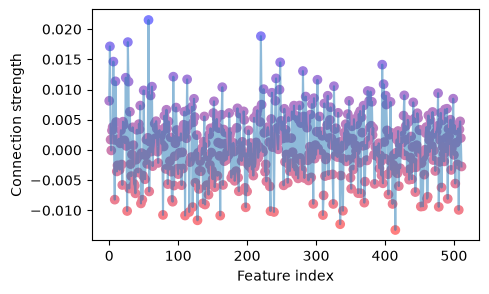

In [21]:
display_pullback_features(U, feature(V, 256), k=5)

In [24]:
display_feature_deembeddings(tl_model, feature(U, 27), k=10)